C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ianjw\AppData\Local\miniconda3\envs\ml\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


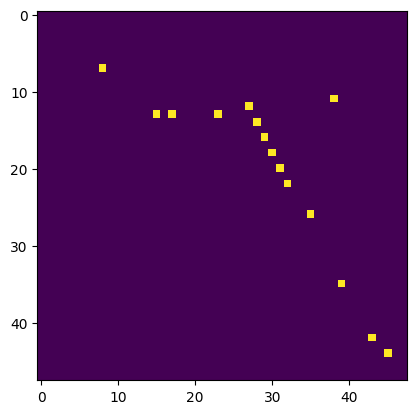

C:\Users\ianjw\AppData\Local\Temp\ipykernel_17104\2829435841.py:36: RuntimeWarning: divide by zero encountered in divide
  x /= np.std(x, axis=0, keepdims=True)
C:\Users\ianjw\AppData\Local\Temp\ipykernel_17104\2829435841.py:36: RuntimeWarning: invalid value encountered in divide
  x /= np.std(x, axis=0, keepdims=True)


((172801, 31), (172801,))

In [1]:
# Load data
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

np.random.seed(42)
SMOOTHING_WINDOW = 256

data = pd.read_csv("WADI_attackdataLABLE.csv") # DOWNLOAD THE DATA FROM THE LINK IN THE PAPER
# x = data[[c for c in data.columns.tolist() if c.endswith("_PV")] + ["TOTAL_CONS_REQUIRED_FLOW"]].values[:-2]
y = data["Attack LABLE (1:No Attack, -1:Attack)"].values[:-2]
req_flow = data["TOTAL_CONS_REQUIRED_FLOW"].values[:-2]

# Derive differences in redundant channels
x_a = data[[c for c in data.columns.tolist() if (c.endswith("_PV") or c.endswith("_SP")) and c[1] == "A"]].values[:-2]
x_b = data[[c for c in data.columns.tolist() if (c.endswith("_PV") or c.endswith("_SP")) and c[1] == "B"]].values[:-2]
x = np.square(x_a - x_b)

other_x = data[[c for c in data.columns.tolist() if (c.endswith("_PV") or c.endswith("_SP")) and c[1] not in ["A", "B"]] + ["TOTAL_CONS_REQUIRED_FLOW"]]
x = np.concatenate([x, other_x.values[:-2]], axis=-1)

# Remove correlated channels
x_corr = np.abs(np.corrcoef(x, rowvar=False))
np.fill_diagonal(x_corr, 0.0)
x_corr = np.triu(x_corr > 0.8)
plt.imshow(x_corr)
plt.show()

for i, j in zip(*np.nonzero(x_corr)):
    x[:, i] = np.square(x[:, i] - x[:, j])

x = x[:, [i for i in range(x.shape[1]) if i not in np.nonzero(x_corr)[1]]]

x -= np.mean(x, axis=0, keepdims=True)
x /= np.std(x, axis=0, keepdims=True)

x = x[:, np.all(np.isfinite(x), axis=0)]

for i in range(x.shape[1]):
    x[:, i] = np.convolve(x[:, i], np.ones(SMOOTHING_WINDOW)/SMOOTHING_WINDOW, mode='same')

x.shape, y.shape

In [2]:
# Separate x_fits
x_esn_fit = x[:5000]
x_rhy_fit = x[4500:5500]

In [3]:
# Find hp
from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for sr in tqdm(np.linspace(0.2, 0.8, 10)):
    for iw in np.linspace(0.25, 1.0, 10):
        for l in np.linspace(0.5, 0.95, 10):
            network = RhythmicNetwork(
                # Tune Rhythmic Sharing
                dt=10,
                input_dims=x.shape[1],
                spectral_radius=sr,
                input_weight=iw,
                average_degree_nodes=8,
                num_nodes=256,
                leakage=l,
                # Rhythmic params
                link_strength_change_ratio=0
            )

            network.train(x_esn_fit.T[:, :-1000])
            pred = network.predict(x_esn_fit.T[:, -1100:], warmup_time=100)
            mse = np.mean(np.square((pred[:, 1:] - x_esn_fit.T[:, -1000:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]


KeyboardInterrupt: 

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.1401e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


New best 0.0001338452 (0.25, -0.1, 0.5333333333333333, 0.001) 0.9999890306379063 0.9999901055490829


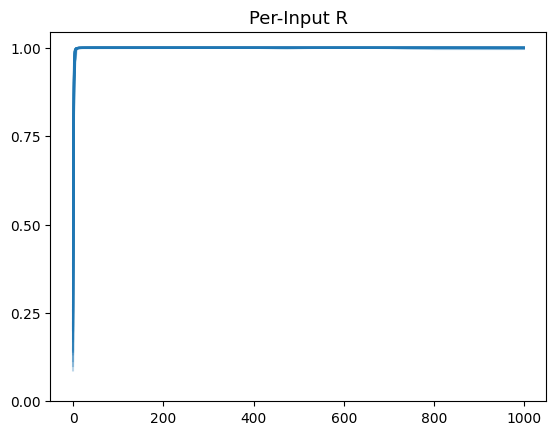

New best 0.0093089740 (0.25, -0.1, 0.6111111111111112, 0.001) 0.7615885768587991 0.7763430759993336


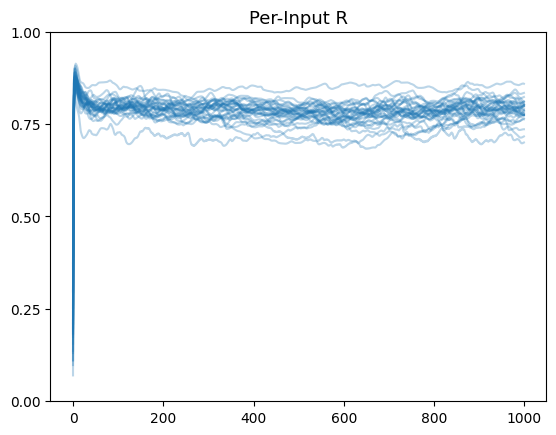

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.12172e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


New best 0.0182237307 (0.25, -0.1, 0.6111111111111112, 0.012) 0.7792936495588411 0.7937624625826268


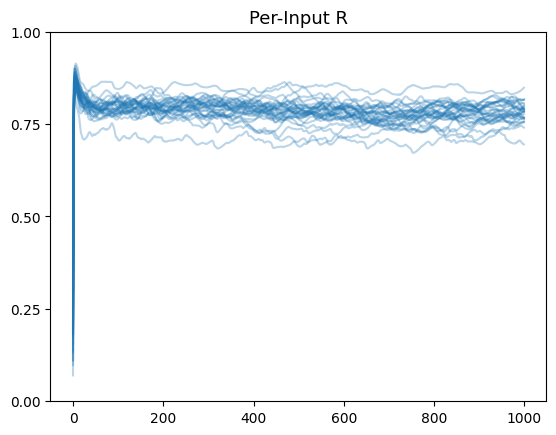

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.20444e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14604e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.1724e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.83149e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rc

New best 0.0214620980 (0.25, -0.14444444444444446, 0.3, 0.001) 0.8929830437375307 0.896658567776349


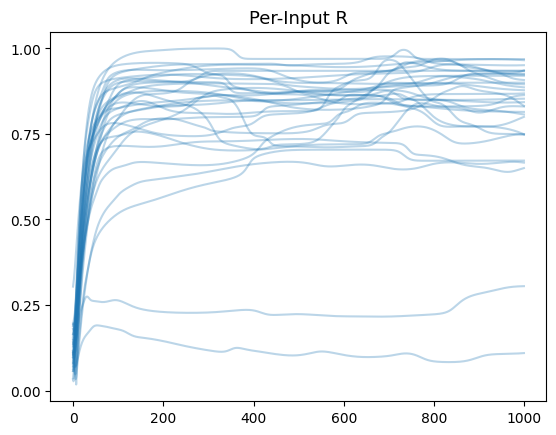

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.43929e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.79827e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.15857e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.59208e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (r

New best 0.0217721674 (0.25, -0.17777777777777778, 0.7666666666666666, 0.05600000000000001) 0.751154517001658 0.7705778503986939


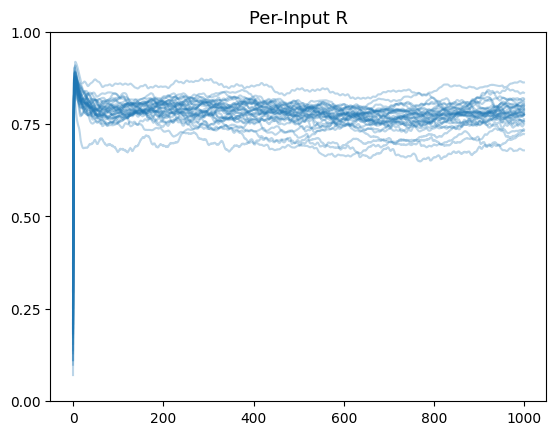

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.77223e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.22222e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.32535e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.33918e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (r

New best 0.0235628837 (0.3333333333333333, -0.14444444444444446, 0.3, 0.001) 0.8926570892442469 0.8964142189054753


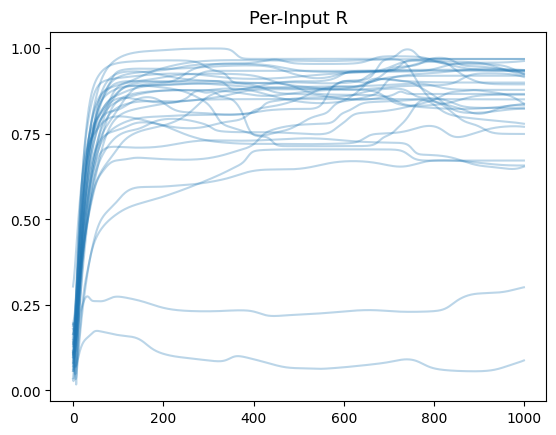

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.2063e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.30599e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.07444e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.1426e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rco

New best 0.0243784397 (0.41666666666666663, -0.14444444444444446, 0.3, 0.001) 0.8920061480676906 0.8961863370953874


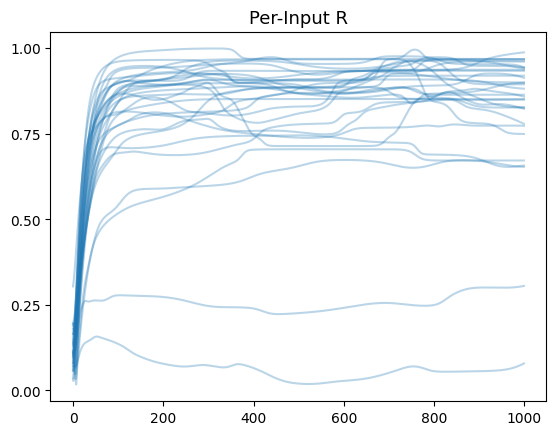

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.07122e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.66154e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.58245e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.02518e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (r

New best 0.0277872454 (0.5833333333333333, -0.14444444444444446, 0.3, 0.001) 0.8904183132082377 0.8954986032639224


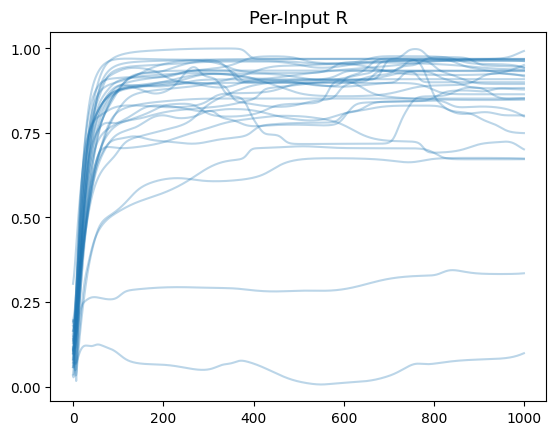

C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.25283e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.24969e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.05328e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.99514e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
C:\Users\ianwh\.conda\envs\machine-learning\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (r

In [62]:
# Find best rhymthic parameters
best_difference = 0
for lsr in np.linspace(0.25, 1, 10):
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)[::-1]):
        for o in np.linspace(0.001, 0.1, 10):
            for e2 in np.linspace(0.3, 1.0, 10):
                network = RhythmicNetwork(
                    # Tune Rhythmic Sharing
                    dt=10,
                    input_dims=x.shape[1],
                    spectral_radius=best_esn_param[0],
                    input_weight=best_esn_param[1],
                    average_degree_nodes=8,
                    num_nodes=256,
                    leakage=best_esn_param[2],
                    # Rhythmic params
                    link_strength_change_ratio=lsr,
                    omega0=o,
                    epsilon1=e1,
                    epsilon2=e2,
                )

                network.train(x_rhy_fit.T, warmup_time=0)
                r = network.get_global_parameters()[0]
    
                diff = np.abs(np.mean(r.T[100:400]) - np.mean(r.T[-400:-100]))#/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[:250]) > 0.7: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o), np.mean(network.get_input_parameters()[0].T[175:200, 11]), np.mean(network.get_input_parameters()[0].T[225:250, 11]))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [4]:
best_esn_param = (0.67, 0.1, 0.5) # (0.8, 1.0, 0.55) # (0.67, 0.1, 0.5)
best_param_rhy = (0.25, -0.20, 0.44, 0.05333333333333334) # (0.25, -0.1, 0.5333333333333333, 0.01) # (0.25, -0.17777777777777778, 0.45555555555555555, 0.05333333333333334)

In [8]:
# Try network on data

network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    input_dims=x.shape[1],
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=8,
    num_nodes=256,
    leakage=best_esn_param[2],
    # Rhythmic params
    link_strength_change_ratio=best_param_rhy[0],
    omega0=best_param_rhy[3],
    epsilon1=best_param_rhy[1],
    epsilon2=best_param_rhy[2],
)

network.train(x.T, warmup_time=0)

100%|█████████████████████████████████████████████████████████████████████████| 172801/172801 [10:09<00:00, 283.54it/s]


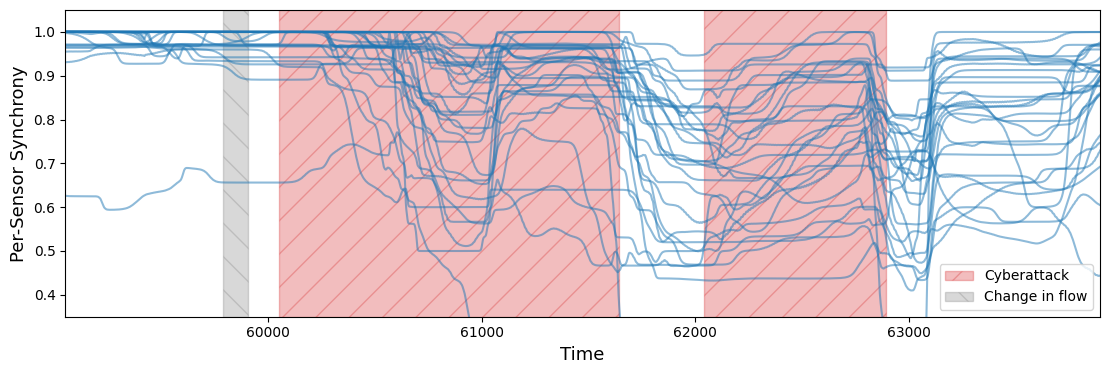

In [10]:
import matplotlib.patches as mpatches

inp_r = network.get_input_parameters()[0]

plt.figure(figsize=(6.4 * 1.75, 4.8 * 0.8))

SMALL_SIZE = 10
MEDIUM_SIZE = 13
BIGGER_SIZE = 20

plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

plt.plot(inp_r.T[1000:], alpha=0.5, color="tab:blue")
plt.axvspan(60053, 60053 + 1591, color="tab:red", hatch="/", alpha=0.3)
plt.axvspan(60053 + 1990, 60053 + 2841, color="tab:red", hatch="/", alpha=0.3)
plt.axvspan(59792, 59910, color="grey", hatch="\\", alpha=0.3)

plt.xlabel("Time")
plt.ylabel("Per-Sensor Synchrony")

plt.xlim([60053 - 1000, 62893 + 1000])
# plt.xlim([5103 - 2000, 5103])
plt.ylim(0.35, 1.05)

plt.legend(
    [mpatches.Patch(color="tab:red", alpha=0.3, hatch="/"), mpatches.Patch(color="grey", alpha=0.3, hatch="\\")],
    ["Cyberattack", "Change in flow"],
    loc="lower right"
)

plt.tight_layout()
plt.savefig("wadi.pdf")
plt.show()

In [7]:
x.shape, inp_r.shape

((172801, 31), (31, 172801))

In [74]:
# Get accurate start/stops
cyberattack_change = np.where(np.abs(y[1:] - y[:-1]))[0]
req_flow_change = np.where(np.abs(req_flow[1:] - req_flow[:-1]))[0]

In [75]:
cyberattack_start_stop
req_flow_start_stop

array([    33,     39,     44,    946,   2682,   3226,   3535,   5690,
         5695,   7134,   9526,   9660,  10735,  13451,  14331,  15636,
        16164,  16964,  19655,  19836,  20860,  21531,  21920,  23885,
        24239,  25130,  30209,  30215,  31705,  31711,  32332,  32948,
        34319,  34325,  34921,  34961,  34967,  35090,  35908,  35930,
        37147,  38378,  41928,  42057,  43003,  43008,  43132,  45491,
        45586,  45592,  46575,  46614,  46732,  47137,  47143,  47182,
        47187,  47616,  47622,  47914,  48009,  48014,  48060,  48066,
        48274,  48279,  48353,  48358,  48532,  48724,  48730,  49153,
        49159,  49732,  49738,  49799,  49805,  49877,  49882,  50334,
        50575,  50586,  53932,  54274,  55327,  59229,  59386,  60050,
        60792,  60798,  60843,  60848,  60903,  60909,  61028,  61033,
        61119,  61130,  61136,  61552,  61558,  61907,  61913,  62058,
        62064,  62092,  62098,  62492,  62791,  62971,  62977,  63989,
      

In [7]:
# Run driftbench on data
from drift_helpers import added_detectors 
from drift_helpers import added_metrics

from driftbench.drift_detection.detectors import (
    RandomGuessDetector,
    RollingMeanDifferenceDetector,
    RollingMeanStandardDeviationDetector,
    AggregateFeatureAlgorithm,
    SlidingKSWINDetector,
    ClusterDetector,
    AutoencoderDetector,
    MMDDetector,
)
from driftbench.drift_detection.metrics import (
    TemporalAUC,
    SoftTAUC,
    AUC,
)

from river.drift import ADWIN, KSWIN, PageHinkley

detectors = [
    # Detectors from driftbench
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=50,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    MMDDetector(window_size=20, stat_size=20, offset=10),
    MMDDetector(window_size=40, stat_size=40, offset=10),
    RollingMeanDifferenceDetector(window_size=20),
    RollingMeanDifferenceDetector(window_size=40),
    RollingMeanStandardDeviationDetector(window_size=20),
    ClusterDetector(n_centers=10, method="kmeans"),
    ClusterDetector(n_centers=10, method="gaussian mixture"),
    ClusterDetector(n_centers=5, method="kmeans"),
    ClusterDetector(n_centers=5, method="gaussian mixture")
]

f1_score = added_metrics.F1_Score()
metrics = [
    f1_score,
    added_metrics.Precision(f1_metric_obj=f1_score),
    added_metrics.Recall(f1_metric_obj=f1_score),
    added_metrics.Delay(f1_metric_obj=f1_score),
    TemporalAUC(rule='step'),
    TemporalAUC(rule='trapez'),
    SoftTAUC(rule='step'),
    AUC(),
]

output = []

Y = np.zeros((x.shape[0]))
cyberattack_change = np.where(np.abs(y[1:] - y[:-1]))[0]
assert len(cyberattack_change) % 2 == 0

for i in range(len(cyberattack_change)//2):
    i = i * 2
    Y[cyberattack_change[i]:cyberattack_change[i+1]] = 1

for detector in tqdm(detectors):
    prediction = detector.predict(x)
    r_prediction = detector.predict(inp_r.T)
    
    output.append({
        "sample": i,
        "detector": detector.name,
        "params": detector.get_hparams(),
        "generic_metrics": {
            metric.name: metric(prediction, Y) for metric in metrics
        },
        "r_metrics": {
            metric.name: metric(r_prediction, Y) for metric in metrics
        }
    })

  0%|                                                                                           | 0/13 [00:00<?, ?it/s]G:\My Drive\Research\Losert Lab\rhythmic_sharing\src\drift_helpers\added_metrics.py:66: RuntimeWarning: invalid value encountered in divide
  return max(TPs/(TPs + FPs))
G:\My Drive\Research\Losert Lab\rhythmic_sharing\src\drift_helpers\added_metrics.py:65: RuntimeWarning: invalid value encountered in divide
  return TPs/(TPs + FPs)
G:\My Drive\Research\Losert Lab\rhythmic_sharing\src\drift_helpers\added_metrics.py:108: RuntimeWarning: Mean of empty slice
  return np.nanmean(first_detections)
G:\My Drive\Research\Losert Lab\rhythmic_sharing\src\drift_helpers\added_metrics.py:66: RuntimeWarning: invalid value encountered in divide
  return max(TPs/(TPs + FPs))
G:\My Drive\Research\Losert Lab\rhythmic_sharing\src\drift_helpers\added_metrics.py:65: RuntimeWarning: invalid value encountered in divide
  return TPs/(TPs + FPs)
G:\My Drive\Research\Losert Lab\rhythmic_sharing

In [14]:
# Separate f1 scores by detector and whether using RS
separated_output = {}
for result in output:
    params = ",".join("%s:%s" % (k, v) for k, v in result["params"].items())
    separated_output[result["detector"] + "," + params] = separated_output.get(result["detector"] + "," + params, {
        "generic": [],
        "rs": []
    })

    separated_output[result["detector"] + "," + params]["generic"].append(result["generic_metrics"])
    separated_output[result["detector"] + "," + params]["rs"].append(result["r_metrics"])

print(separated_output[result["detector"] + "," + params]["rs"][0].keys())
for k, v in separated_output.items():
    print(k, np.nanmean([i["Precision"] for i in v["generic"]]), np.nanmean([i["Precision"] for i in v["rs"]]))

dict_keys(['Precision', 'Recall', 'F1_Score', 'Delay', 'TAUC-step', 'TAUC-trapez', 'SoftTAUC', 'AUC'])
AutoencoderDetector,activation:tanh,lr:0.001,optim:adam,num_epochs:50,hidden_layers:[80, 50, 20, 10, 2] 0.06331422421202904 0.07613626851929355
AutoencoderDetector,activation:tanh,lr:0.0001,optim:adam,num_epochs:100,hidden_layers:[80, 50, 20, 10, 2] 0.06250500083650357 0.07630505300471524
AutoencoderDetector,activation:tanh,lr:0.0001,optim:adam,num_epochs:10,hidden_layers:[80, 20, 4] 0.2047719497014736 0.15860927753982848
MMDDetector, 0.31148172201550106 0.36232680246973603
RollingMeanDifferenceDetector,window_size:20,center:False,fillna_strategy:None 0.871268656716418 0.4393939393939394
RollingMeanDifferenceDetector,window_size:40,center:False,fillna_strategy:None 0.9454148471615721 0.5420560747663551
RollingMeanStandardDeviationDetector, 0.9122055674518201 0.43661971830985913
ClusterDetector,method:kmeans,n_centers:10 1.0 0.5412658227848102
ClusterDetector,method:gaussian mixture,n_

In [9]:
import pickle

with open('wadi_detector.pkl', 'wb') as file:
    # Use pickle.dump() to write the data to the file
    pickle.dump(result, file)